In [ ]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import nltk
nltk.download('punkt', force=True)
nltk.download('stopwords', force=True)
nltk.download('wordnet', force=True)
nltk.download('vader_lexicon', force=True)
nltk.download('averaged_perceptron_tagger', force=True)
nltk.download('punkt_tab', force=True)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sbhalerao\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sbhalerao\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sbhalerao\AppData\Roaming\nltk_data...
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sbhalerao\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sbhalerao\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sbhalerao\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

### 2. Data Cleaning

In [ ]:
df = pd.read_csv("record_mapping.csv", encoding='utf-8-sig')
df.sample(5)

,Focus Group,Value Index,Content
857,DOCE Discovery Session | Zoning,17,Zoning map amendments/zone change projects – m...
158,DOCE Discovery Session | Building Inspectors G...,57,2 years since it’s been referred to Law and no...
323,DOCE Discovery Session | Supervisors Group,27,"Collaboration – phone text, email, teams"
1393,BAA Discovery Session | BAA,96,Handheld recorder for hearings
755,DOCE Discovery Session | Central Permit Office,19,History of certificates will be in IPS – trans...


In [ ]:
df.loc[df['Content'].str.contains('Swapnil|swapnil', case=False, na=False), 'Content']

#drop rows where 'Content' contains 'Swapnil' or 'swapnil'
df = df[~df['Content'].str.contains('Swapnil|swapnil', case=False, na=False)]

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text)
    filtered_tokens = [w.lower() for w in tokens if w.isalpha() and w.lower() not in stop_words]

    lemmas = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    return ' '.join(lemmas)

df['processed_content'] = df['Content'].apply(preprocess_text)
print(df[['Content', 'processed_content']].head(10))

                                              Content  \
0                       Jordan – Office Manager, 5mos   
1           Mastajah – Admin Aides, 6mos (ma-sta-jah)   
2                          Shawna – Admin Aide, 1.5yr   
5       Role – general role and main responsibilities   
6   Phone calls from the public – complaint line, ...   
7                                     Letters folding   
8       Help at the window, people who in come person   
9                       Jordan: Help pick up projects   
10                 Day to day – writing tickets, send   
11                             Ownership verification   

                                    processed_content  
0                               jordan office manager  
1                                 mastajah admin aide  
2                                   shawna admin aide  
5               role general role main responsibility  
6   phone call public complaint line generalized q...  
7                                   

## Feature Extraction

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

# Rebuild processed_content here if the preprocessing cell has not been run.
if 'processed_content' not in df.columns:
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    def preprocess_text(text):
        tokens = word_tokenize(str(text))
        filtered_tokens = [w.lower() for w in tokens if w.isalpha() and w.lower() not in stop_words]
        lemmas = [lemmatizer.lemmatize(token) for token in filtered_tokens]
        return ' '.join(lemmas)

    df['processed_content'] = df['Content'].apply(preprocess_text)


def get_category(text):
    tokens = str(text).split()
    if not tokens:
        return 'unknown'
    return Counter(tokens).most_common(1)[0][0]

sia = SentimentIntensityAnalyzer()

def get_sentiment_label(text):
    text = str(text)
    compound_score = sia.polarity_scores(text)['compound']
    token_count = len([token for token in text.split() if token.strip()])

    if token_count == 1 and -0.05 < compound_score < 0.05:
        return 'neutral'
    if compound_score >= 0.05:
        return 'positive'
    if compound_score <= -0.05:
        return 'negative'
    return 'neutral'

# Build a label column from the cleaned text so the model has a target to learn.
df['label'] = df['processed_content'].apply(get_sentiment_label)
df = df[df['label'].isin(['positive', 'negative', 'neutral'])].copy()

# Create a category from the dominant word in the cleaned content.
df['category'] = df['processed_content'].apply(get_category)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['processed_content'])
y = df['label'].map({'positive': 1, 'negative': 0, 'neutral': 2}).values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(df[['Content', 'processed_content', 'category', 'label']].head(10))

Feature matrix shape: (1626, 2215)
Target vector shape: (1626,)
                                              Content  \
0                       Jordan – Office Manager, 5mos   
1           Mastajah – Admin Aides, 6mos (ma-sta-jah)   
2                          Shawna – Admin Aide, 1.5yr   
5       Role – general role and main responsibilities   
6   Phone calls from the public – complaint line, ...   
7                                     Letters folding   
8       Help at the window, people who in come person   
9                       Jordan: Help pick up projects   
10                 Day to day – writing tickets, send   
11                             Ownership verification   

                                    processed_content   category     label  
0                               jordan office manager     jordan   neutral  
1                                 mastajah admin aide   mastajah   neutral  
2                                   shawna admin aide     shawna   neutral  


In [ ]:
df.loc[df['label'].str.contains('neutral', case=False, na=False), 'Content']

0                           Jordan – Office Manager, 5mos
1               Mastajah – Admin Aides, 6mos (ma-sta-jah)
2                              Shawna – Admin Aide, 1.5yr
5           Role – general role and main responsibilities
7                                         Letters folding
                              ...                        
1620                                        Expectations:
1621                                               Tools:
1622    J: eTAx- puliing tax data developing phase lis...
1624    R: external data sources, NY open data portal,...
1627    Software to interface with public, how sylode ...
Name: Content, Length: 940, dtype: str

## Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Training

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[218.,330.,752.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-1.79,-1.37,-0.55]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 2215)","[[ 1., 0., 0.,..., 0., 2., 2.], [13., 4., 0.,..., 1., 3., 8.], [ 3., 5., 0.,..., 0., 3.,21.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 2215)","[[-7.57,-8.26,-8.26,...,-8.26,-7.16,-7.16], [-5.88,-6.9 ,-8.51,...,-7.82,-7.13,-6.32], [-7.32,-6.91,-8.71,...,-8.71,-7.32,-5.61]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2215


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7392638036809815
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.49      0.55        55
           1       0.68      0.63      0.65        83
           2       0.78      0.86      0.82       188

    accuracy                           0.74       326
   macro avg       0.70      0.66      0.68       326
weighted avg       0.73      0.74      0.73       326

Confusion Matrix:
 [[ 27   6  22]
 [  8  52  23]
 [  8  18 162]]


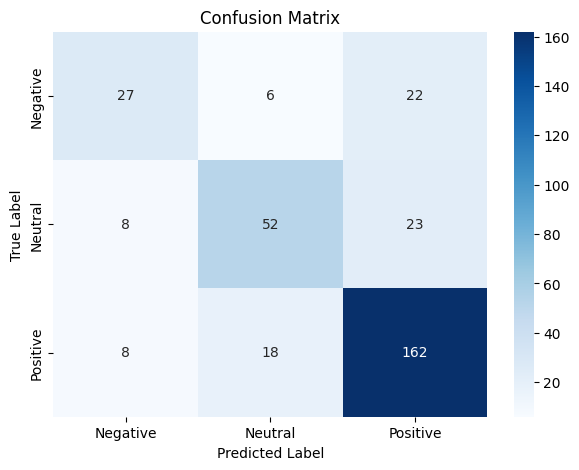

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[
            'Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()


def get_vader_sentiment(text):
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'


print(get_vader_sentiment(df['Content'].iloc[0]))  # Example usage on the first row of the DataFrame

df['vader_sentiment'] = df['Content'].apply(get_vader_sentiment)
print(df[['Content', 'vader_sentiment']].head())

neutral
                                             Content vader_sentiment
0                      Jordan – Office Manager, 5mos         neutral
1          Mastajah – Admin Aides, 6mos (ma-sta-jah)         neutral
2                         Shawna – Admin Aide, 1.5yr         neutral
5      Role – general role and main responsibilities         neutral
6  Phone calls from the public – complaint line, ...        negative


In [ ]:
from sklearn.metrics import accuracy_score

df['vader_sentiment'] = df['Content'].apply(get_vader_sentiment)

vader_labels = df['vader_sentiment'].map(
    {'positive': 1, 'negative': 0, 'neutral': -1})
valid_indices = vader_labels != -1

print("VADER Sentiment Accuracy compared to labels:")
print(accuracy_score(y[valid_indices], vader_labels[valid_indices]))

VADER Sentiment Accuracy compared to labels:
0.9210526315789473


In [ ]:
def predict_sentiment(text):
    processed = preprocess_text(text)
    vectorized = vectorizer.transform([processed])
    pred = model.predict(vectorized)[0]
    return {0: 'negative', 1: 'positive', 2: 'neutral'}.get(pred, 'neutral')


for text in df['Content'].sample(random_state=42):
    print(f"Sentence: {text} => Sentiment: {predict_sentiment(text)}")

Sentence: Not much existing documentation for IPS – figure it out, trial and error => Sentiment: negative


In [ ]:
import joblib

joblib.dump(model, 'sentiment_nb_model.joblib')
joblib.dump(vectorizer, 'count_vectorizer.joblib')

['count_vectorizer.joblib']

In [ ]:
# find the reords where vader sentiment is different from label sentiment
df[df['label'] != df['vader_sentiment']]

,Focus Group,Value Index,Content,processed_content,label,category,vader_sentiment
37,7DOCE Discovery Session | Admin Aides Group 1,37,S: Scheduling,scheduling,neutral,scheduling,negative
39,7DOCE Discovery Session | Admin Aides Group 1,39,Not all explciitly told at the same time who i...,explciitly told time e pat commercial electric...,neutral,pat,negative
49,7DOCE Discovery Session | Admin Aides Group 1,49,Our phones are on a time limit – 5min max – dr...,phone time limit max drop automatically known ...,negative,phone,neutral
94,7DOCE Discovery Session | Admin Aides Group 1,94,S: Doesn’t use Excel on day to day,use excel day day,positive,day,neutral
104,DOCE Discovery Session | Building Inspectors G...,3,Dan: Housing > Building – 2018 (8 yrs),dan housing building yr,neutral,dan,positive
...,...,...,...,...,...,...,...
1518,CPC Discovery Session | CPC,24,Codes – Viki will call Codes if someone applie...,code viki call code someone applied rental reg...,neutral,code,negative
1537,CPC Discovery Session | CPC,43,Could pay it and sue civilly – technically new...,could pay sue civilly technically new owner re...,positive,could,negative
1538,CPC Discovery Session | CPC,44,Viki: BAA fines – BAA needs to update their fi...,viki baa fine baa need update fine timeline mo...,positive,baa,negative
1541,CPC Discovery Session | CPC,47,Send to BAA when they need to verify the amoun...,send baa need verify amount always sure due an...,positive,send,negative


In [ ]:
# filter out record where processed contains less than 5 words
df['word_count'] = df['processed_content'].apply(lambda x: len(x.split()))
df = df[df['word_count'] >= 5]

In [ ]:
df.sample(5)

,Focus Group,Value Index,Content,processed_content,label,category,vader_sentiment,word_count
807,DOCE Discovery Session | Central Permit Office,71,Not in IPS - likes Camino timestamps so you kn...,ip like camino timestamps know need know delet...,positive,know,negative,9
1184,Discovery Session | Law,30,Petitioner and respondent (2 parties) - City o...,petitioner respondent party city syracuse v pr...,positive,petitioner,neutral,8
1230,Discovery Session | Assessment,17,Don’t get the full picture if they’re large plans,get full picture large plan,neutral,get,neutral,5
477,DOCE Discovery Session | Housing Inspectors Group,55,When select OG – entering same info for every ...,select og entering info every case would helpf...,negative,info,negative,14
343,DOCE Discovery Session | Supervisors Group,47,Resubdivided – looking at new resubbed address...,resubdivided looking new resubbed address see ...,neutral,resubbed,neutral,14


In [ ]:
# df [vader_sentiment] == negative then move to pain_points.csv
pain_points_df = df[df['vader_sentiment'] == 'negative']
# df [vader_sentiment] == positive then move to expectations.csv
expectations_df = df[df['vader_sentiment'] == 'positive']

In [ ]:
pain_points_df.to_csv('challenges&expectations/pain_points.csv', index=False, encoding='utf-8-sig')
expectations_df.to_csv('challenges&expectations/expectations.csv', index=False, encoding='utf-8-sig')

In [ ]:
df.to_csv('./labeled_records.csv', index=False, encoding='utf-8-sig')

In [ ]:
IPS_related_challenges = pain_points_df.loc[
    pain_points_df['Content'].str.contains('IPS', case=False, na=False),
    ['Focus Group', 'Content', 'processed_content', 'category', 'label', 'vader_sentiment']
].copy()
IPS_related_challenges.to_csv('challenges&expectations/IPS_related_challenges.csv', index=False, encoding='utf-8-sig')
